In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.stats import linregress
from btreport.utils.plotting import plots, plots_survival
%matplotlib inline

Load merged datasheet (Vasari, Midline Shift Quantifications, Imaging Features, Clinical Data)

In [5]:
merged_data = pd.read_csv("btreport/patient_metadata/datasheets/cleaned_merged.csv")

# print(list(merged_data.keys())) # Uncomment this to see which keys are available for selection

# Select keys we want to analyze from merged_data.
vasari_list = [k for k in merged_data if "vasari" in k.lower() and not any(s in k.lower() for s in ["text_report", "region_proportions"])]
midline_shift = ['brats23_metadata_flattened__global__max_midline_shift_mm', 'midline_summary__mean_distance_mm', 'midline_summary__p95_distance_mm', 'brats23_metadata_flattened__global__level_max_shift']
mutation_status = [key for key in merged_data.keys() if any(s in key.lower() for s in ["mgmt_status", "idh_status"])]
brats_masks = ["GBM_Subjects_Spreadsheet__nr_volume", "GBM_Subjects_Spreadsheet__er_volume" , "GBM_Subjects_Spreadsheet__et_volume" , "GBM_Subjects_Spreadsheet__tumor_volume" , "GBM_Subjects_Spreadsheet__tumor_burden" , "GBM_Subjects_Spreadsheet__etiv", "GBM_Subjects_Spreadsheet__resection_status"]
demo_list = ["GBM_Subjects_Spreadsheet__age" , "GBM_Subjects_Spreadsheet__sex", "UCSF-PDGM-Clinical__Final pathologic diagnosis (WHO 2021)"]

# Death event for survival analysis
merged_data["event"] = 1 


# Attach names to binary variables
merged_data["GBM_Subjects_Spreadsheet__sex"] = [bool(x) for x in merged_data["GBM_Subjects_Spreadsheet__sex"]-1]
merged_data["GBM_Subjects_Spreadsheet__sex"] = [
    "Male" if bool(x) else "Female" for x in (merged_data["GBM_Subjects_Spreadsheet__sex"] - 1)
]

merged_data['GBM_Subjects_Spreadsheet__mgmt_status'] = [
    "Methylated" if bool(x) else "Unmethylated" for x in (merged_data["GBM_Subjects_Spreadsheet__mgmt_status"])
]

merged_data['GBM_Subjects_Spreadsheet__idh_status'] = [
    "Mutant" if bool(x) else "Wildtype" for x in (merged_data["GBM_Subjects_Spreadsheet__idh_status"])
]

merged_data['GBM_Subjects_Spreadsheet__resection_status'] = [
    "Gross Total Resection (>90%)" if bool(x) else "Biopsy/Subtotal Resection (<90%)" for x in (merged_data["GBM_Subjects_Spreadsheet__resection_status"])
]

merged_data['brats23_metadata_flattened__global__max_midline_shift_mm'] = [abs(x) for x in merged_data['brats23_metadata_flattened__global__max_midline_shift_mm']]

VASARI Features

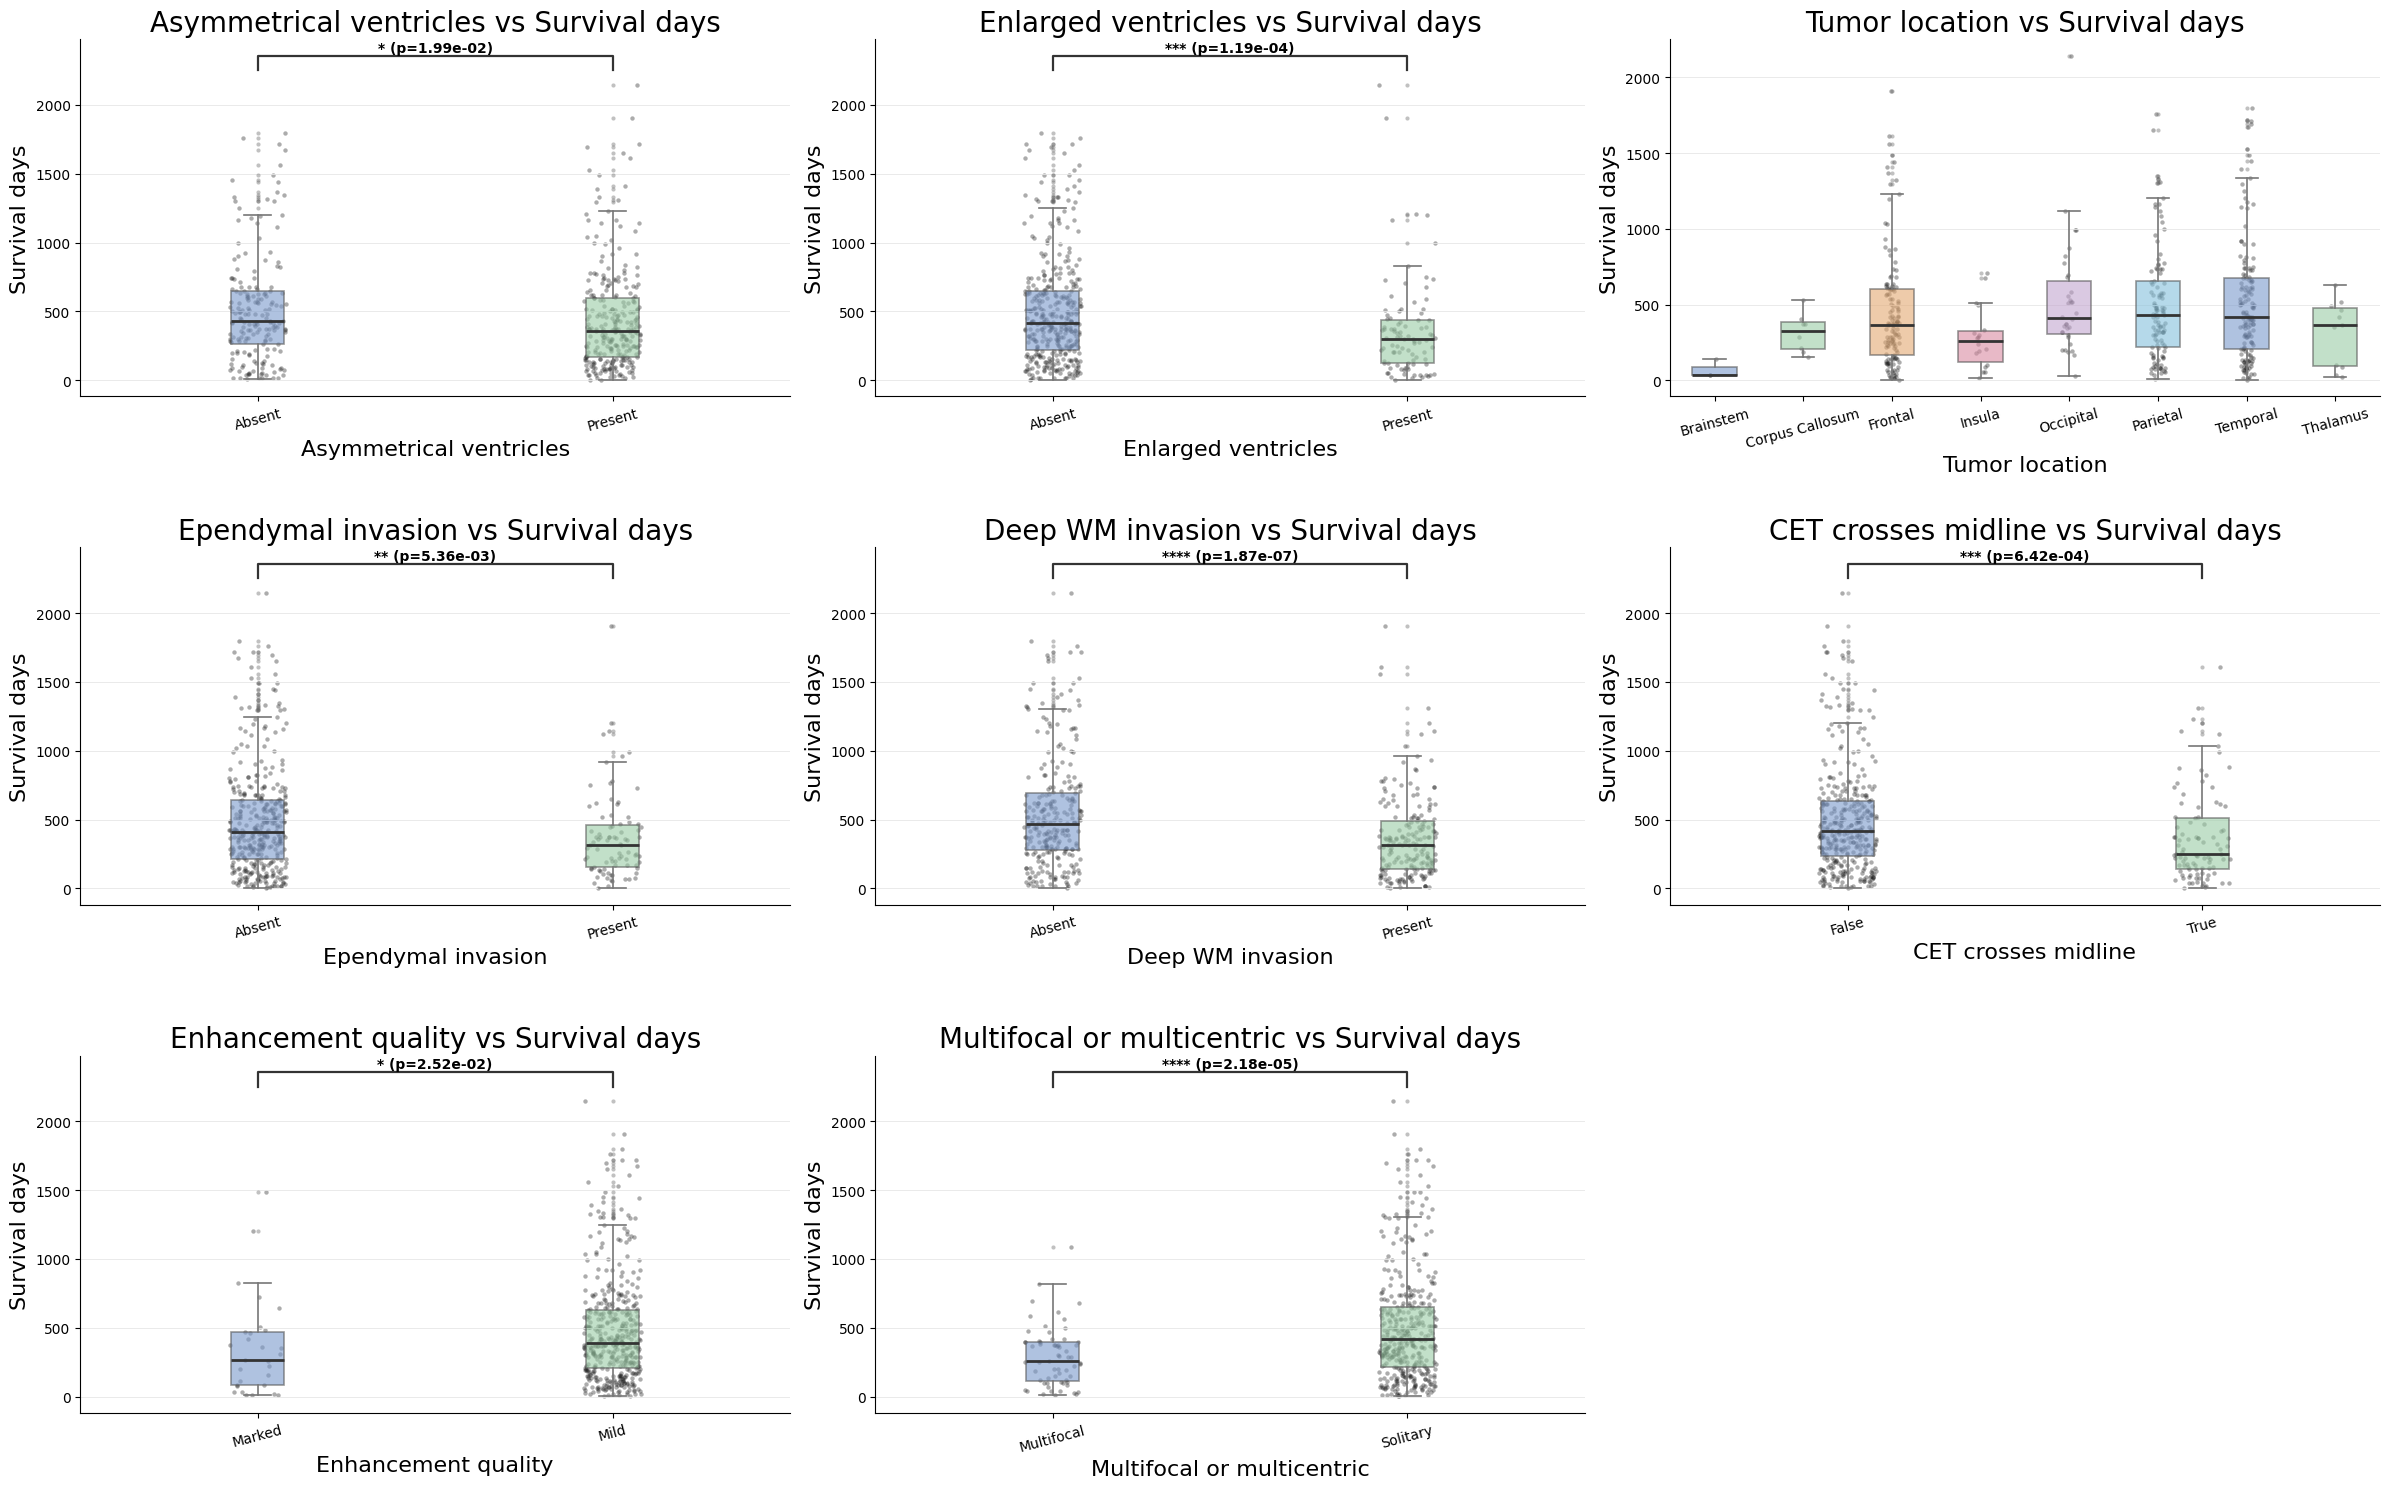

In [9]:
plots(df=merged_data,x_list=vasari_list, only_significant=True)

BraTS Segmentation Features

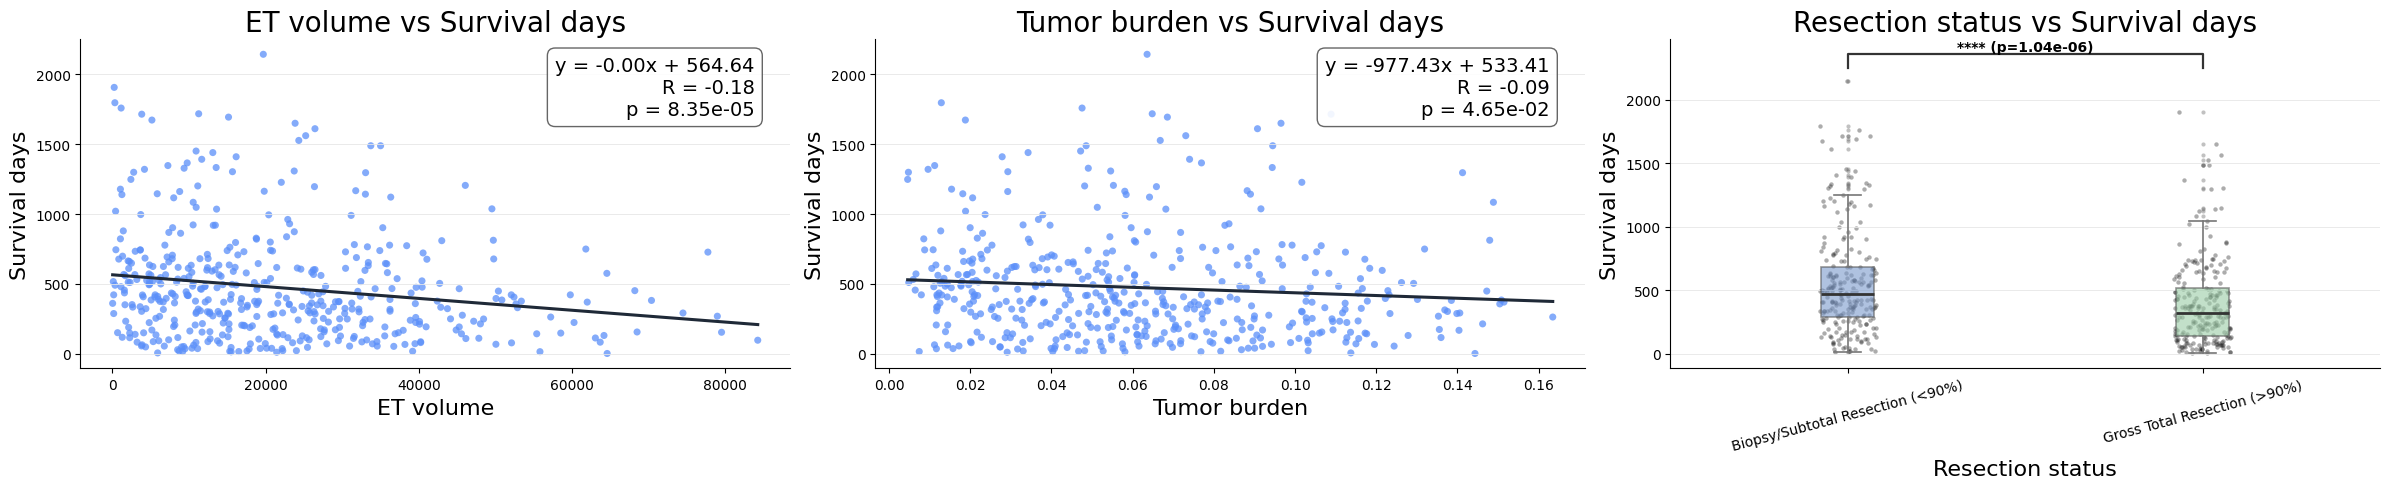

In [4]:
plots(df=merged_data,x_list=brats_masks, only_significant=True)

Patient Demographics

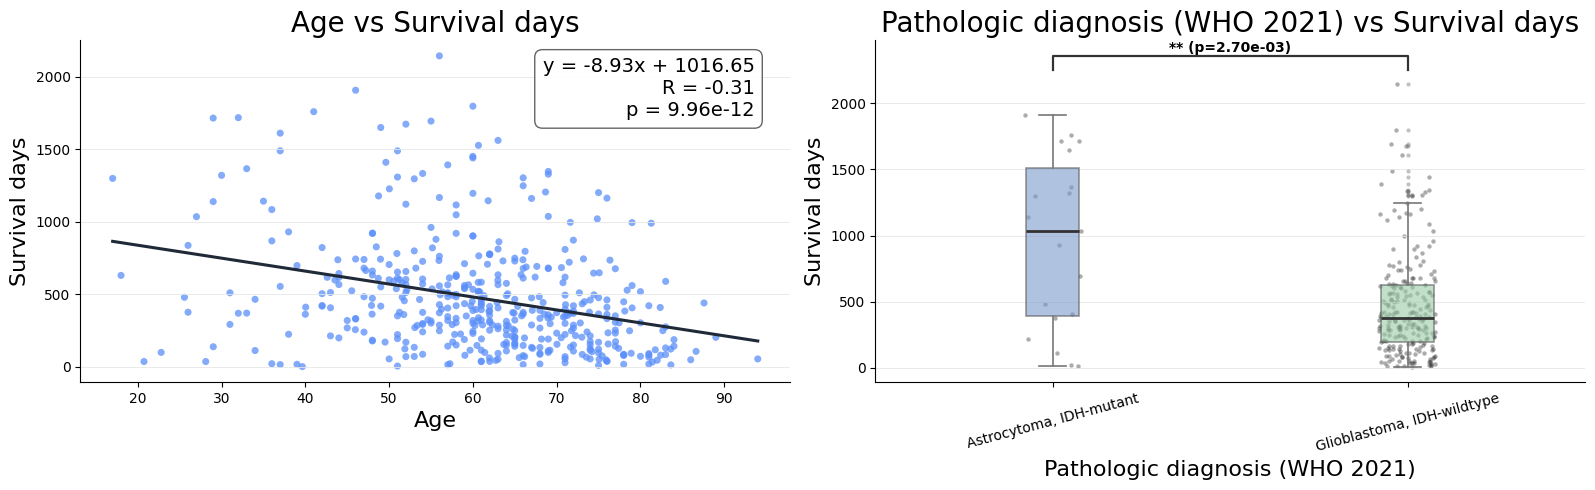

In [5]:
plots(df=merged_data,x_list=demo_list, only_significant=True)


Mutation Status

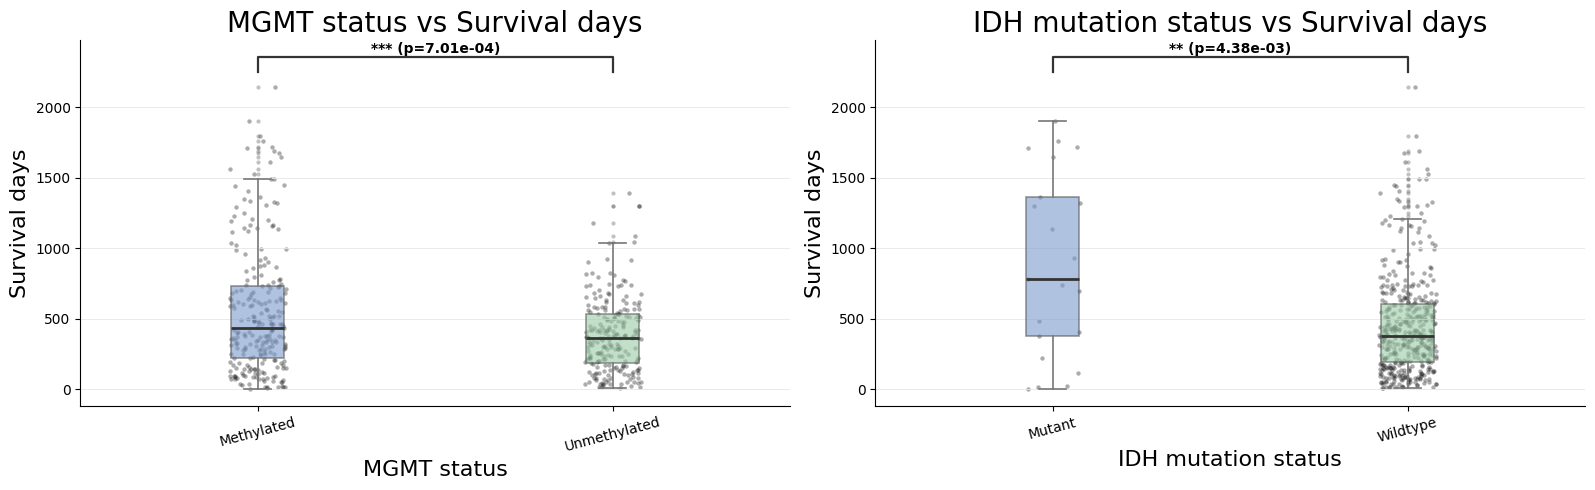

In [6]:
plots(df=merged_data,x_list=mutation_status,only_significant=True) 

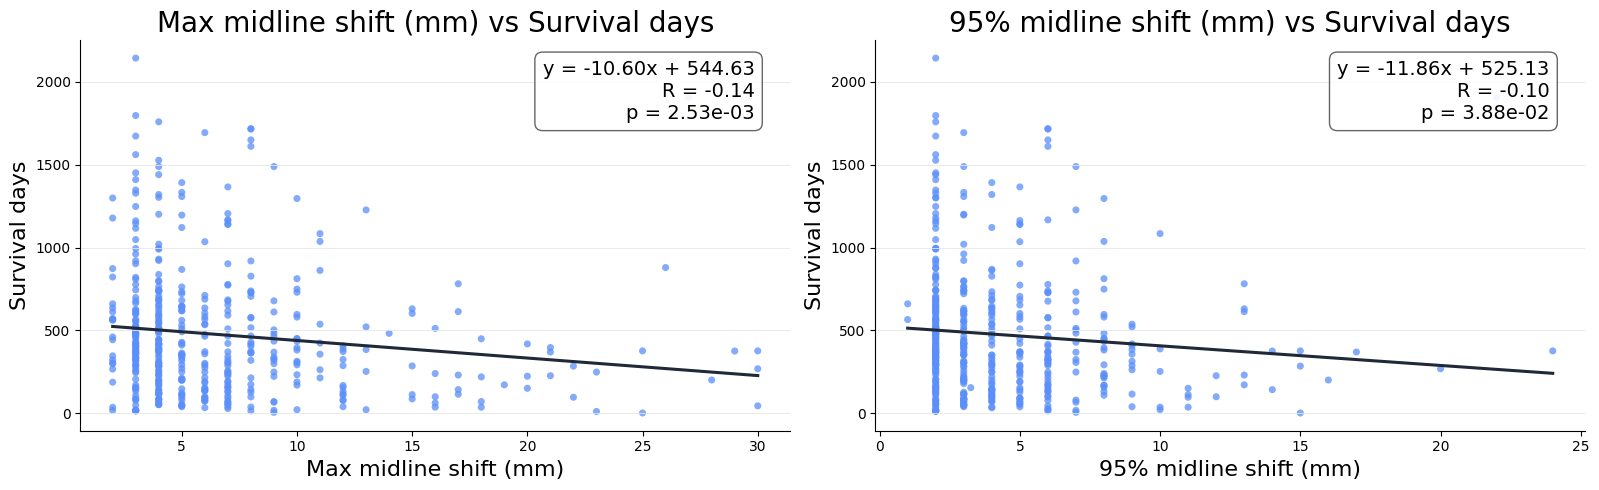

In [7]:
plots(df=merged_data,x_list=midline_shift,only_significant=True)

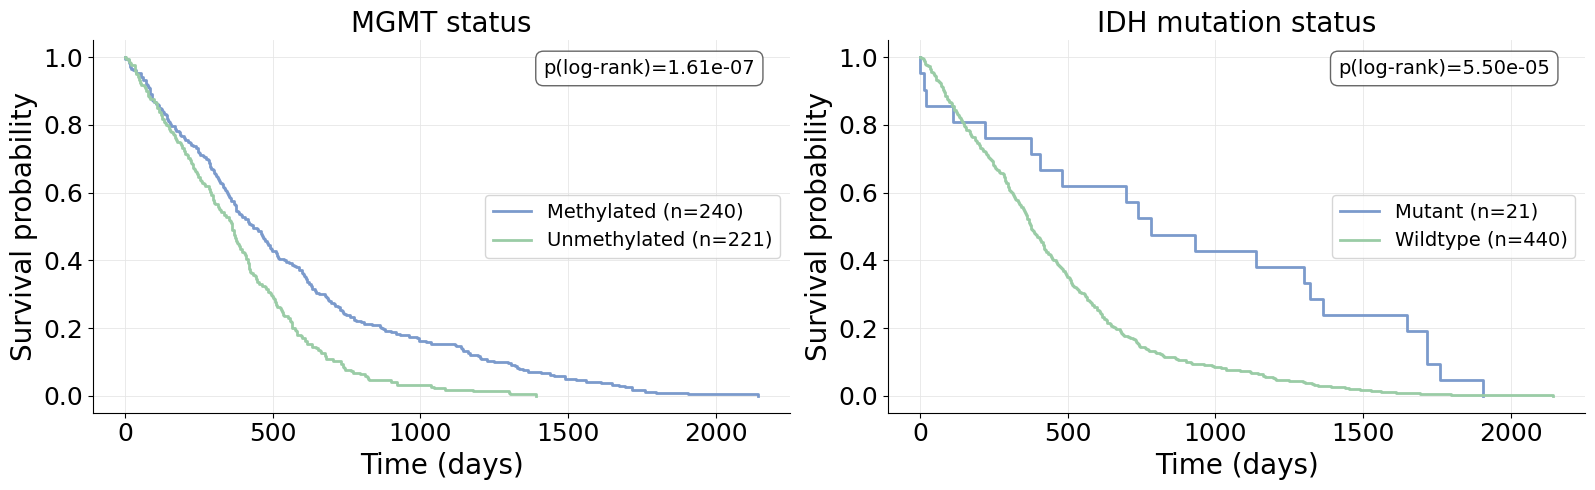

In [ ]:
plots_survival(
    df=merged_data,
    x_list=mutation_status,
    only_significant=True, alpha=0.01,
    save_path='./patient_metadata/assets/mutation_vs_surv_KM.png',
)

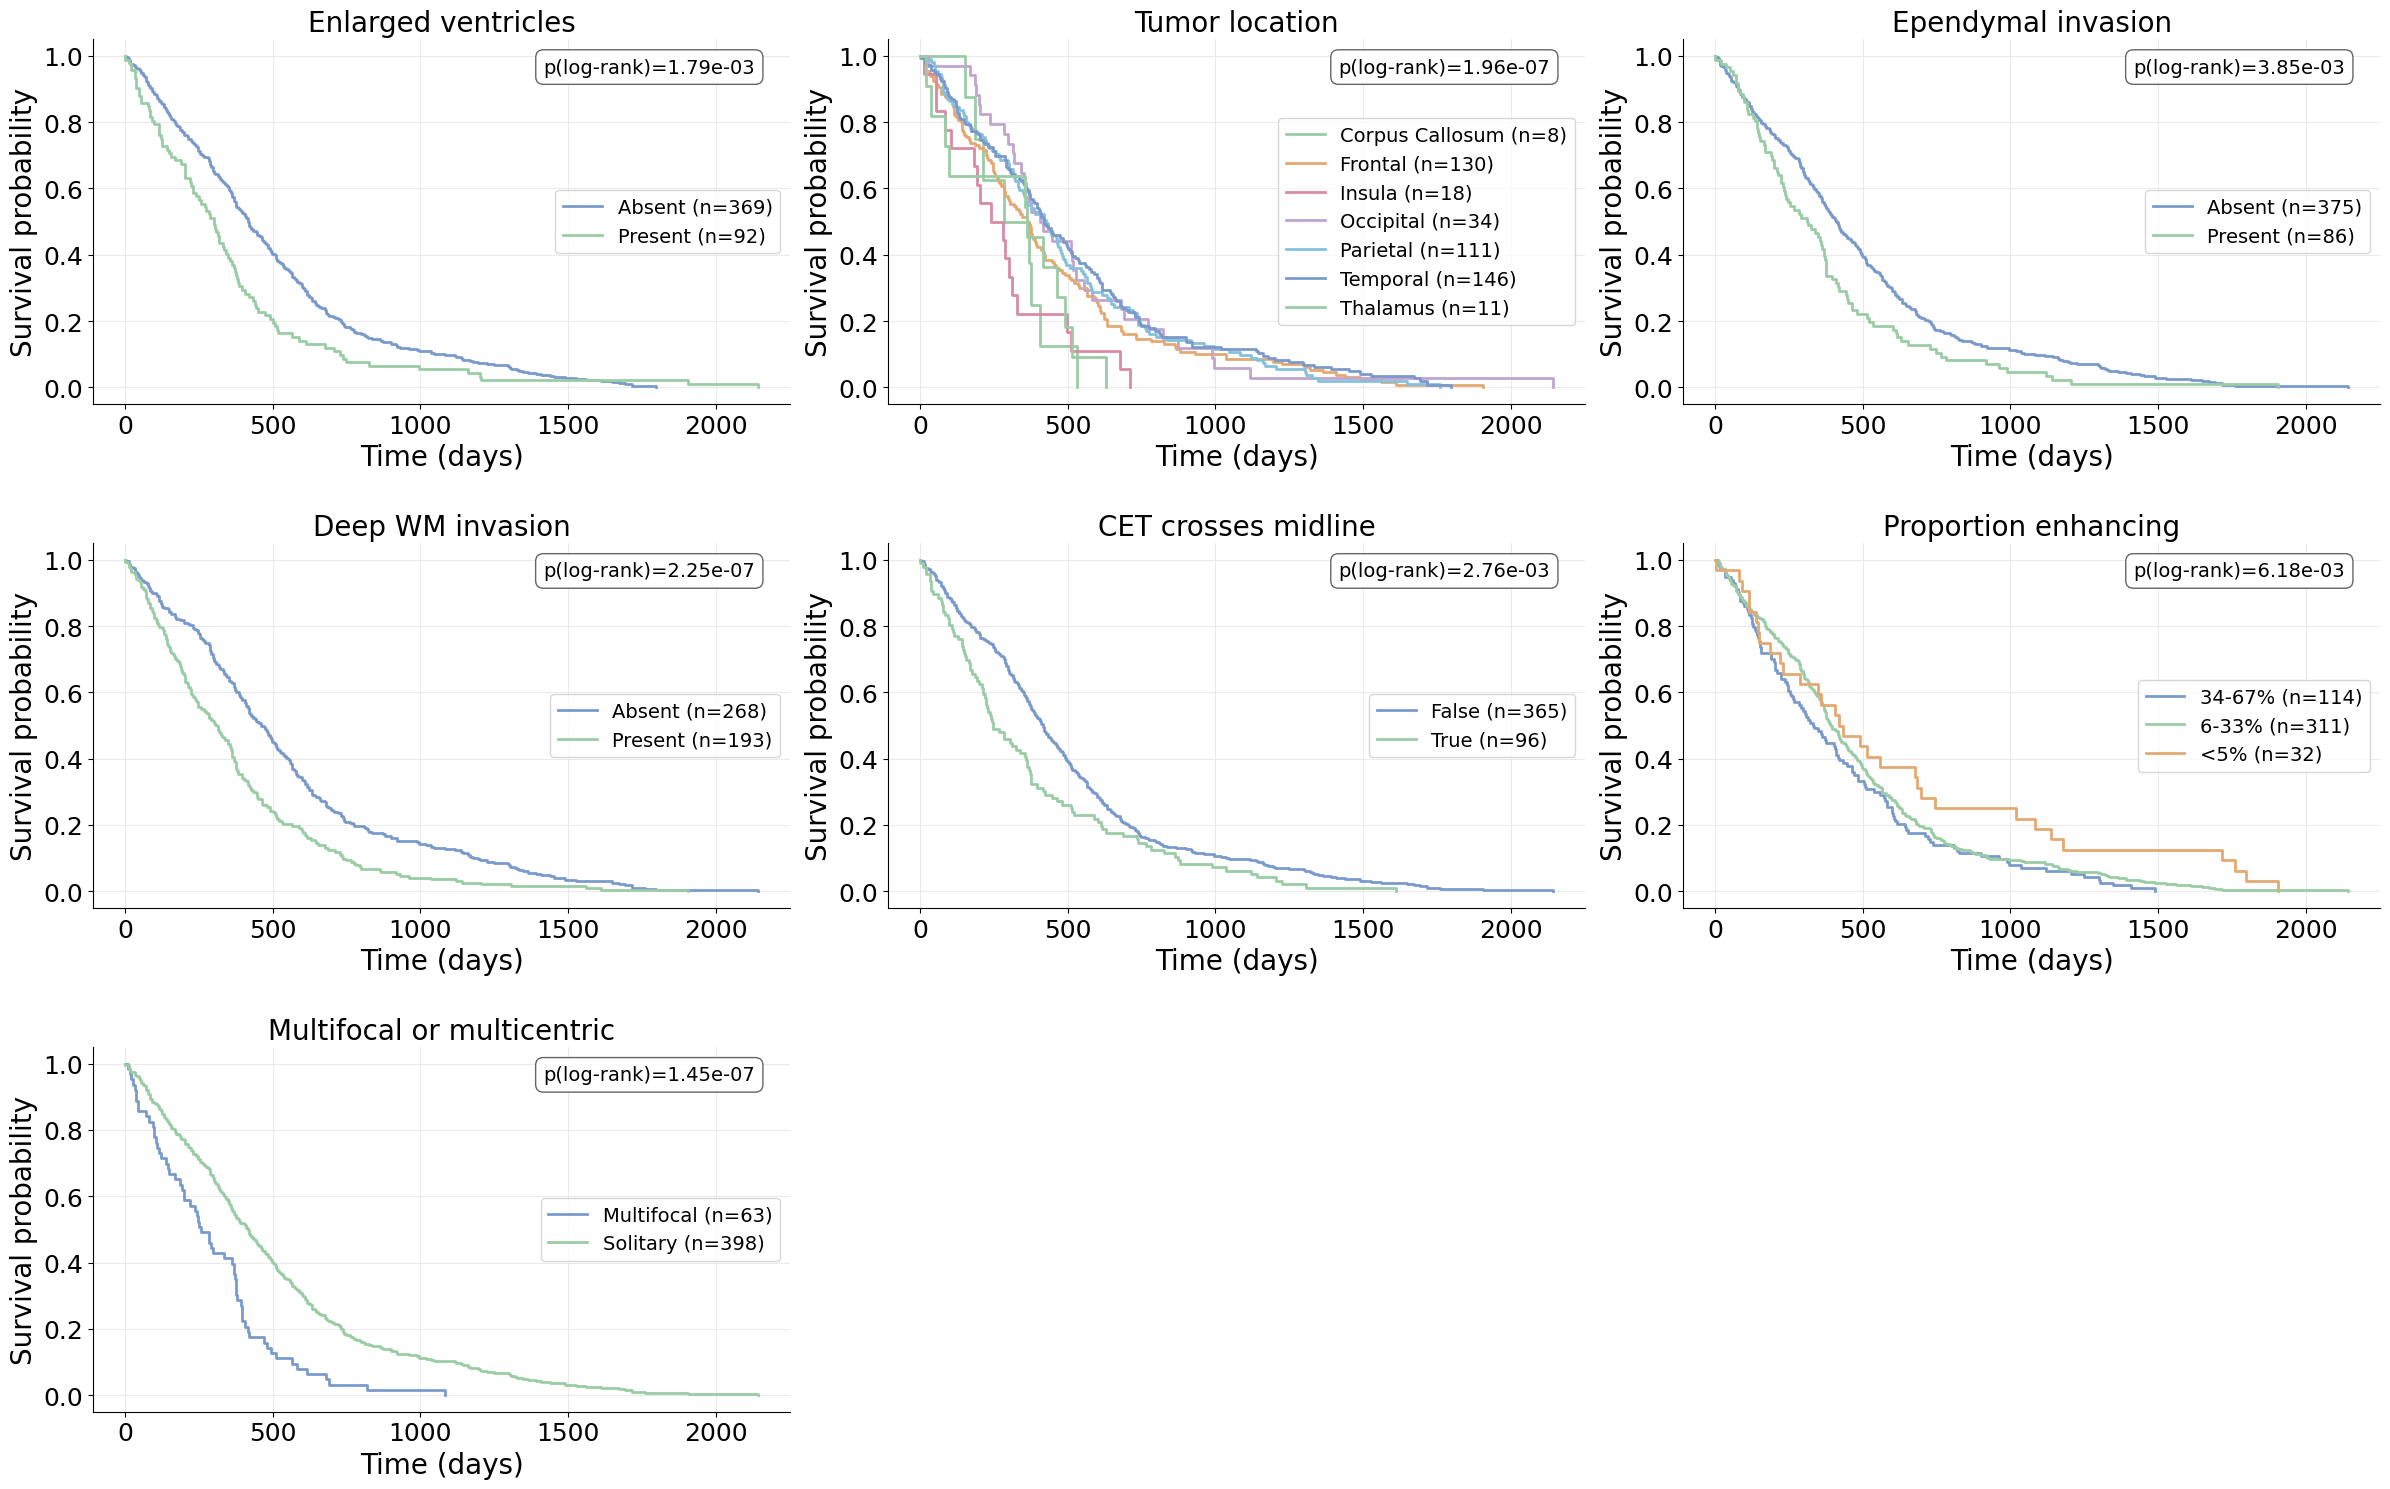

In [ ]:
plots_survival(df=merged_data,x_list=vasari_list, only_significant=True, alpha=0.01, save_path='./patient_metadata/assets/vasari_vs_surv_KM.png',)


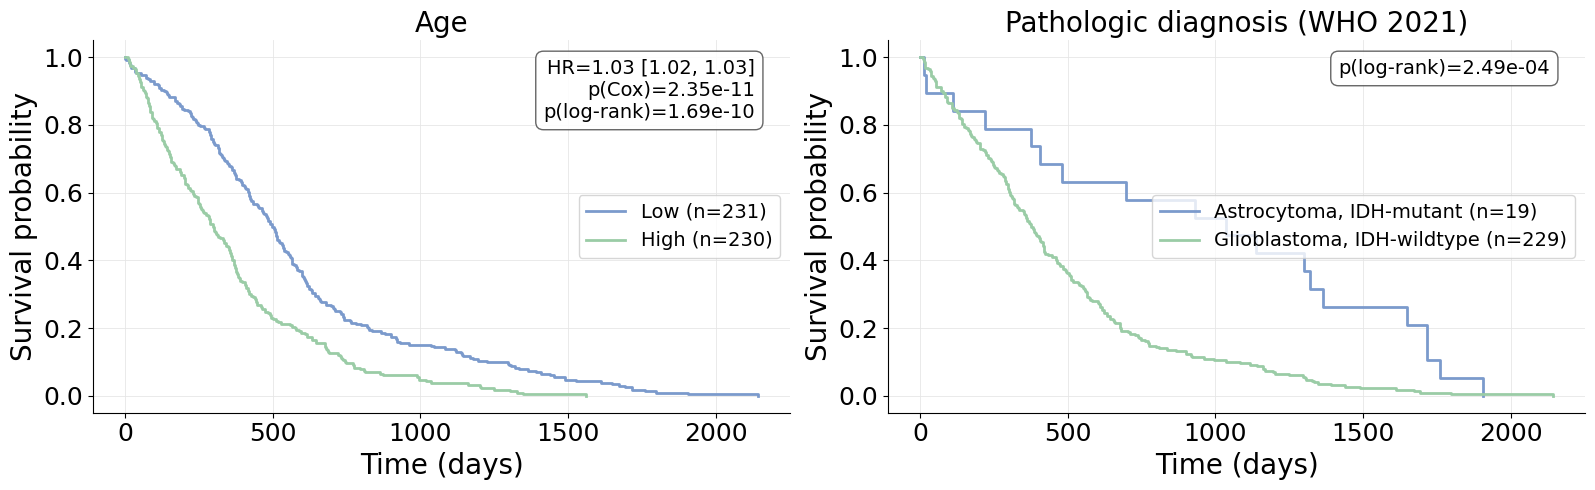

In [ ]:
plots_survival(df=merged_data,x_list=demo_list, only_significant=True, alpha=0.01, save_path='./patient_metadata/assets/demographics_vs_surv_KM.png',)


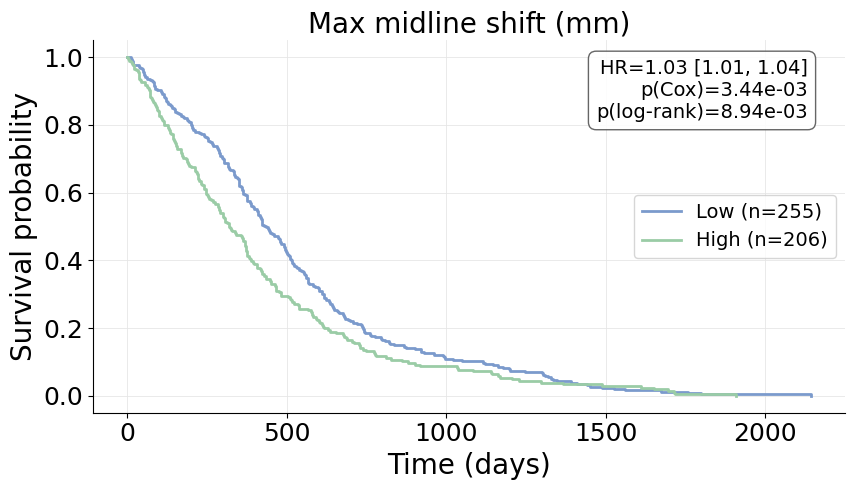

In [11]:
plots_survival(df=merged_data,x_list=midline_shift,only_significant=True, alpha=0.01,save_path='./assets/midline_vs_surv_KM.png',)

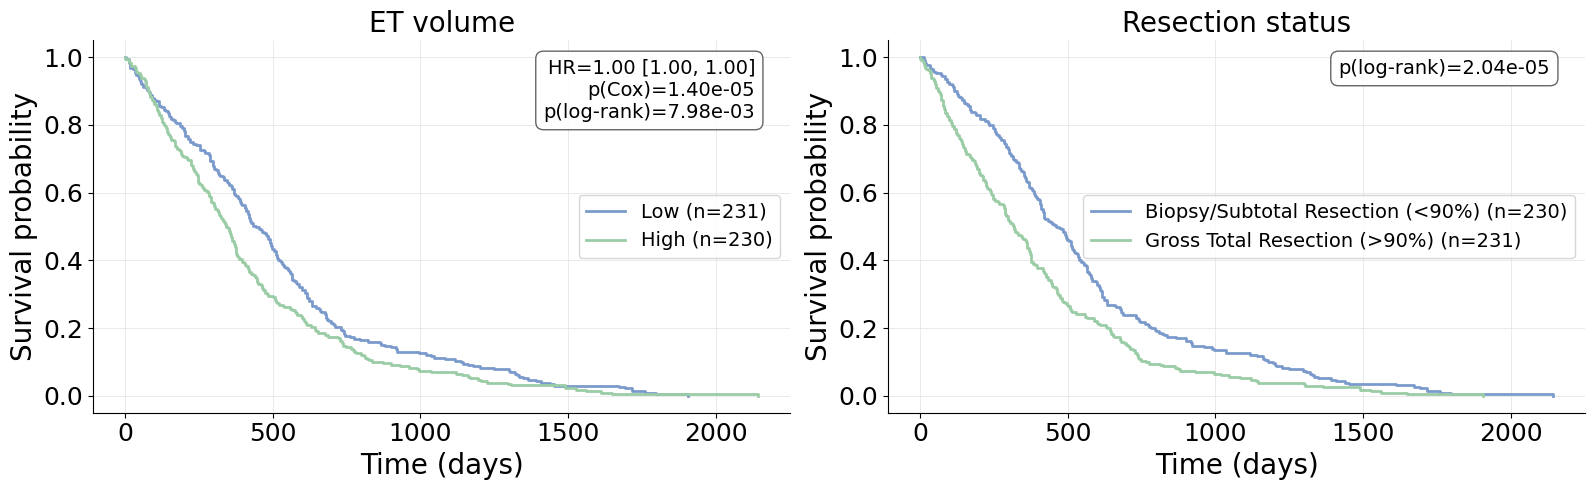

In [ ]:
plots_survival(df=merged_data,x_list=brats_masks, only_significant=True, alpha=0.01,save_path='./patient_metadata/assets/lesionstats_vs_surv_KM.png',)

['brats23_metadata_flattened__global__vasari_asymmetrical_ventricles', 'brats23_metadata_flattened__global__vasari_enlarged_ventricles', 'brats23_metadata_flattened__global__vasari_f1_tumour_location', 'brats23_metadata_flattened__global__vasari_f11_thickness_of_enhancing_margin', 'brats23_metadata_flattened__global__vasari_f14_proportion_of_oedema', 'brats23_metadata_flattened__global__vasari_f19_ependymal_invasion', 'brats23_metadata_flattened__global__vasari_f2_side_of_tumour_epicenter', 'brats23_metadata_flattened__global__vasari_f20_cortical_involvement', 'brats23_metadata_flattened__global__vasari_f21_deep_wm_invasion', 'brats23_metadata_flattened__global__vasari_f23_cet_crosses_midline', 'brats23_metadata_flattened__global__vasari_f24_satellites', 'brats23_metadata_flattened__global__vasari_f3_eloquent_brain', 'brats23_metadata_flattened__global__vasari_f4_enhancement_quality', 'brats23_metadata_flattened__global__vasari_f5_proportion_enhancing', 'brats23_metadata_flattened__glo

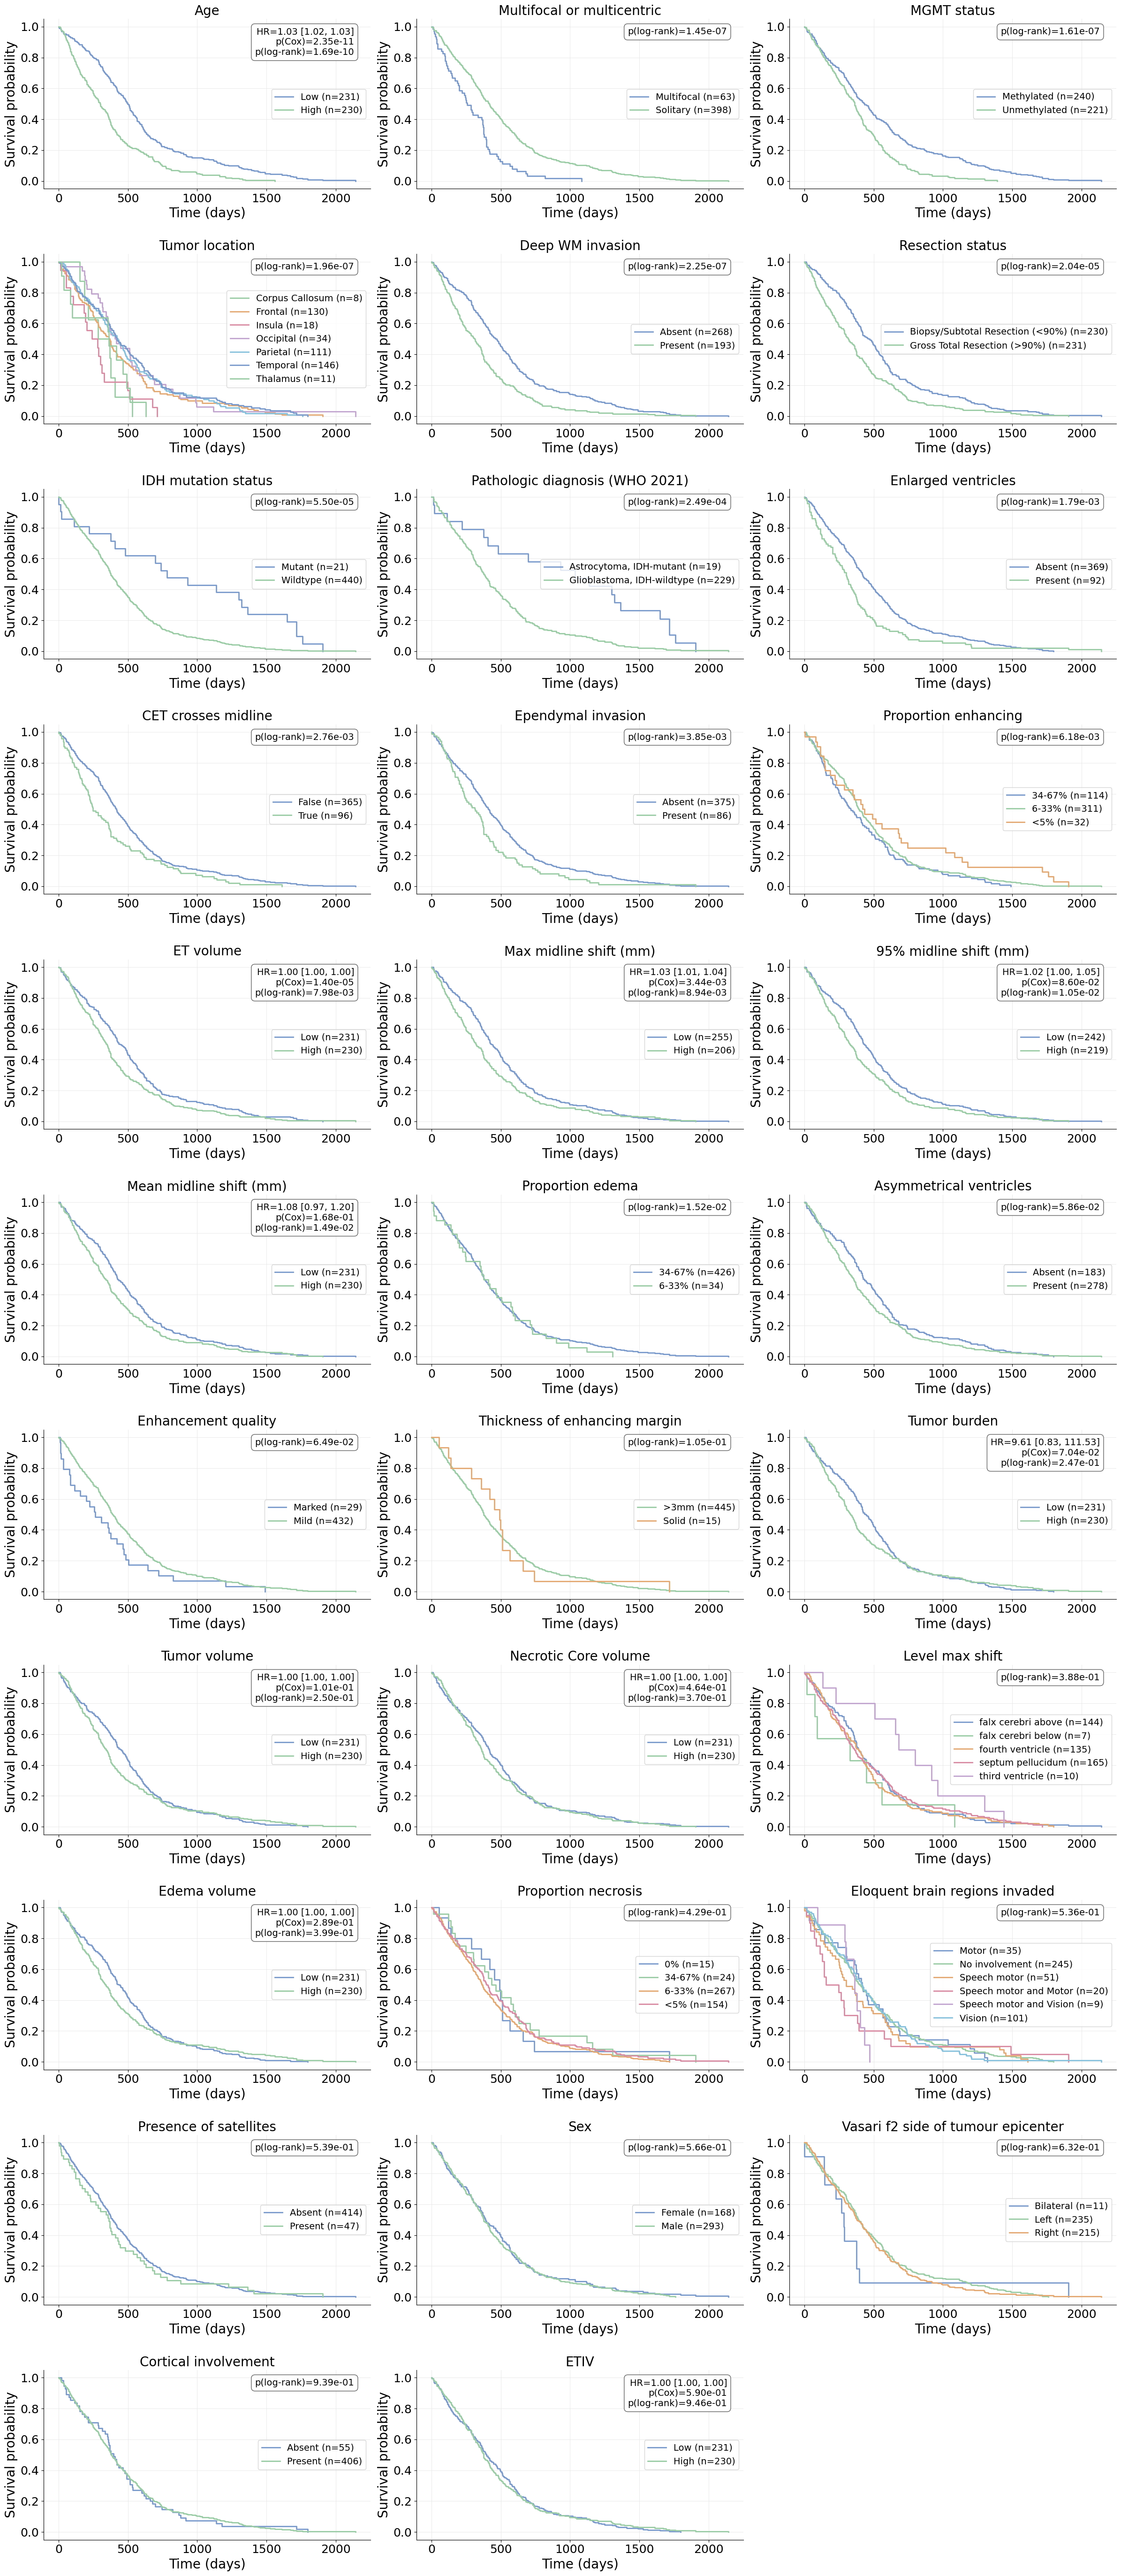

In [ ]:
features=vasari_list+ midline_shift+ mutation_status+ brats_masks+demo_list
print(features)
plots_survival(df=merged_data,x_list=features, only_significant=False, alpha=0.05,save_path='./patient_metadata/assets/all_vs_surv_KM.png',sort=True)

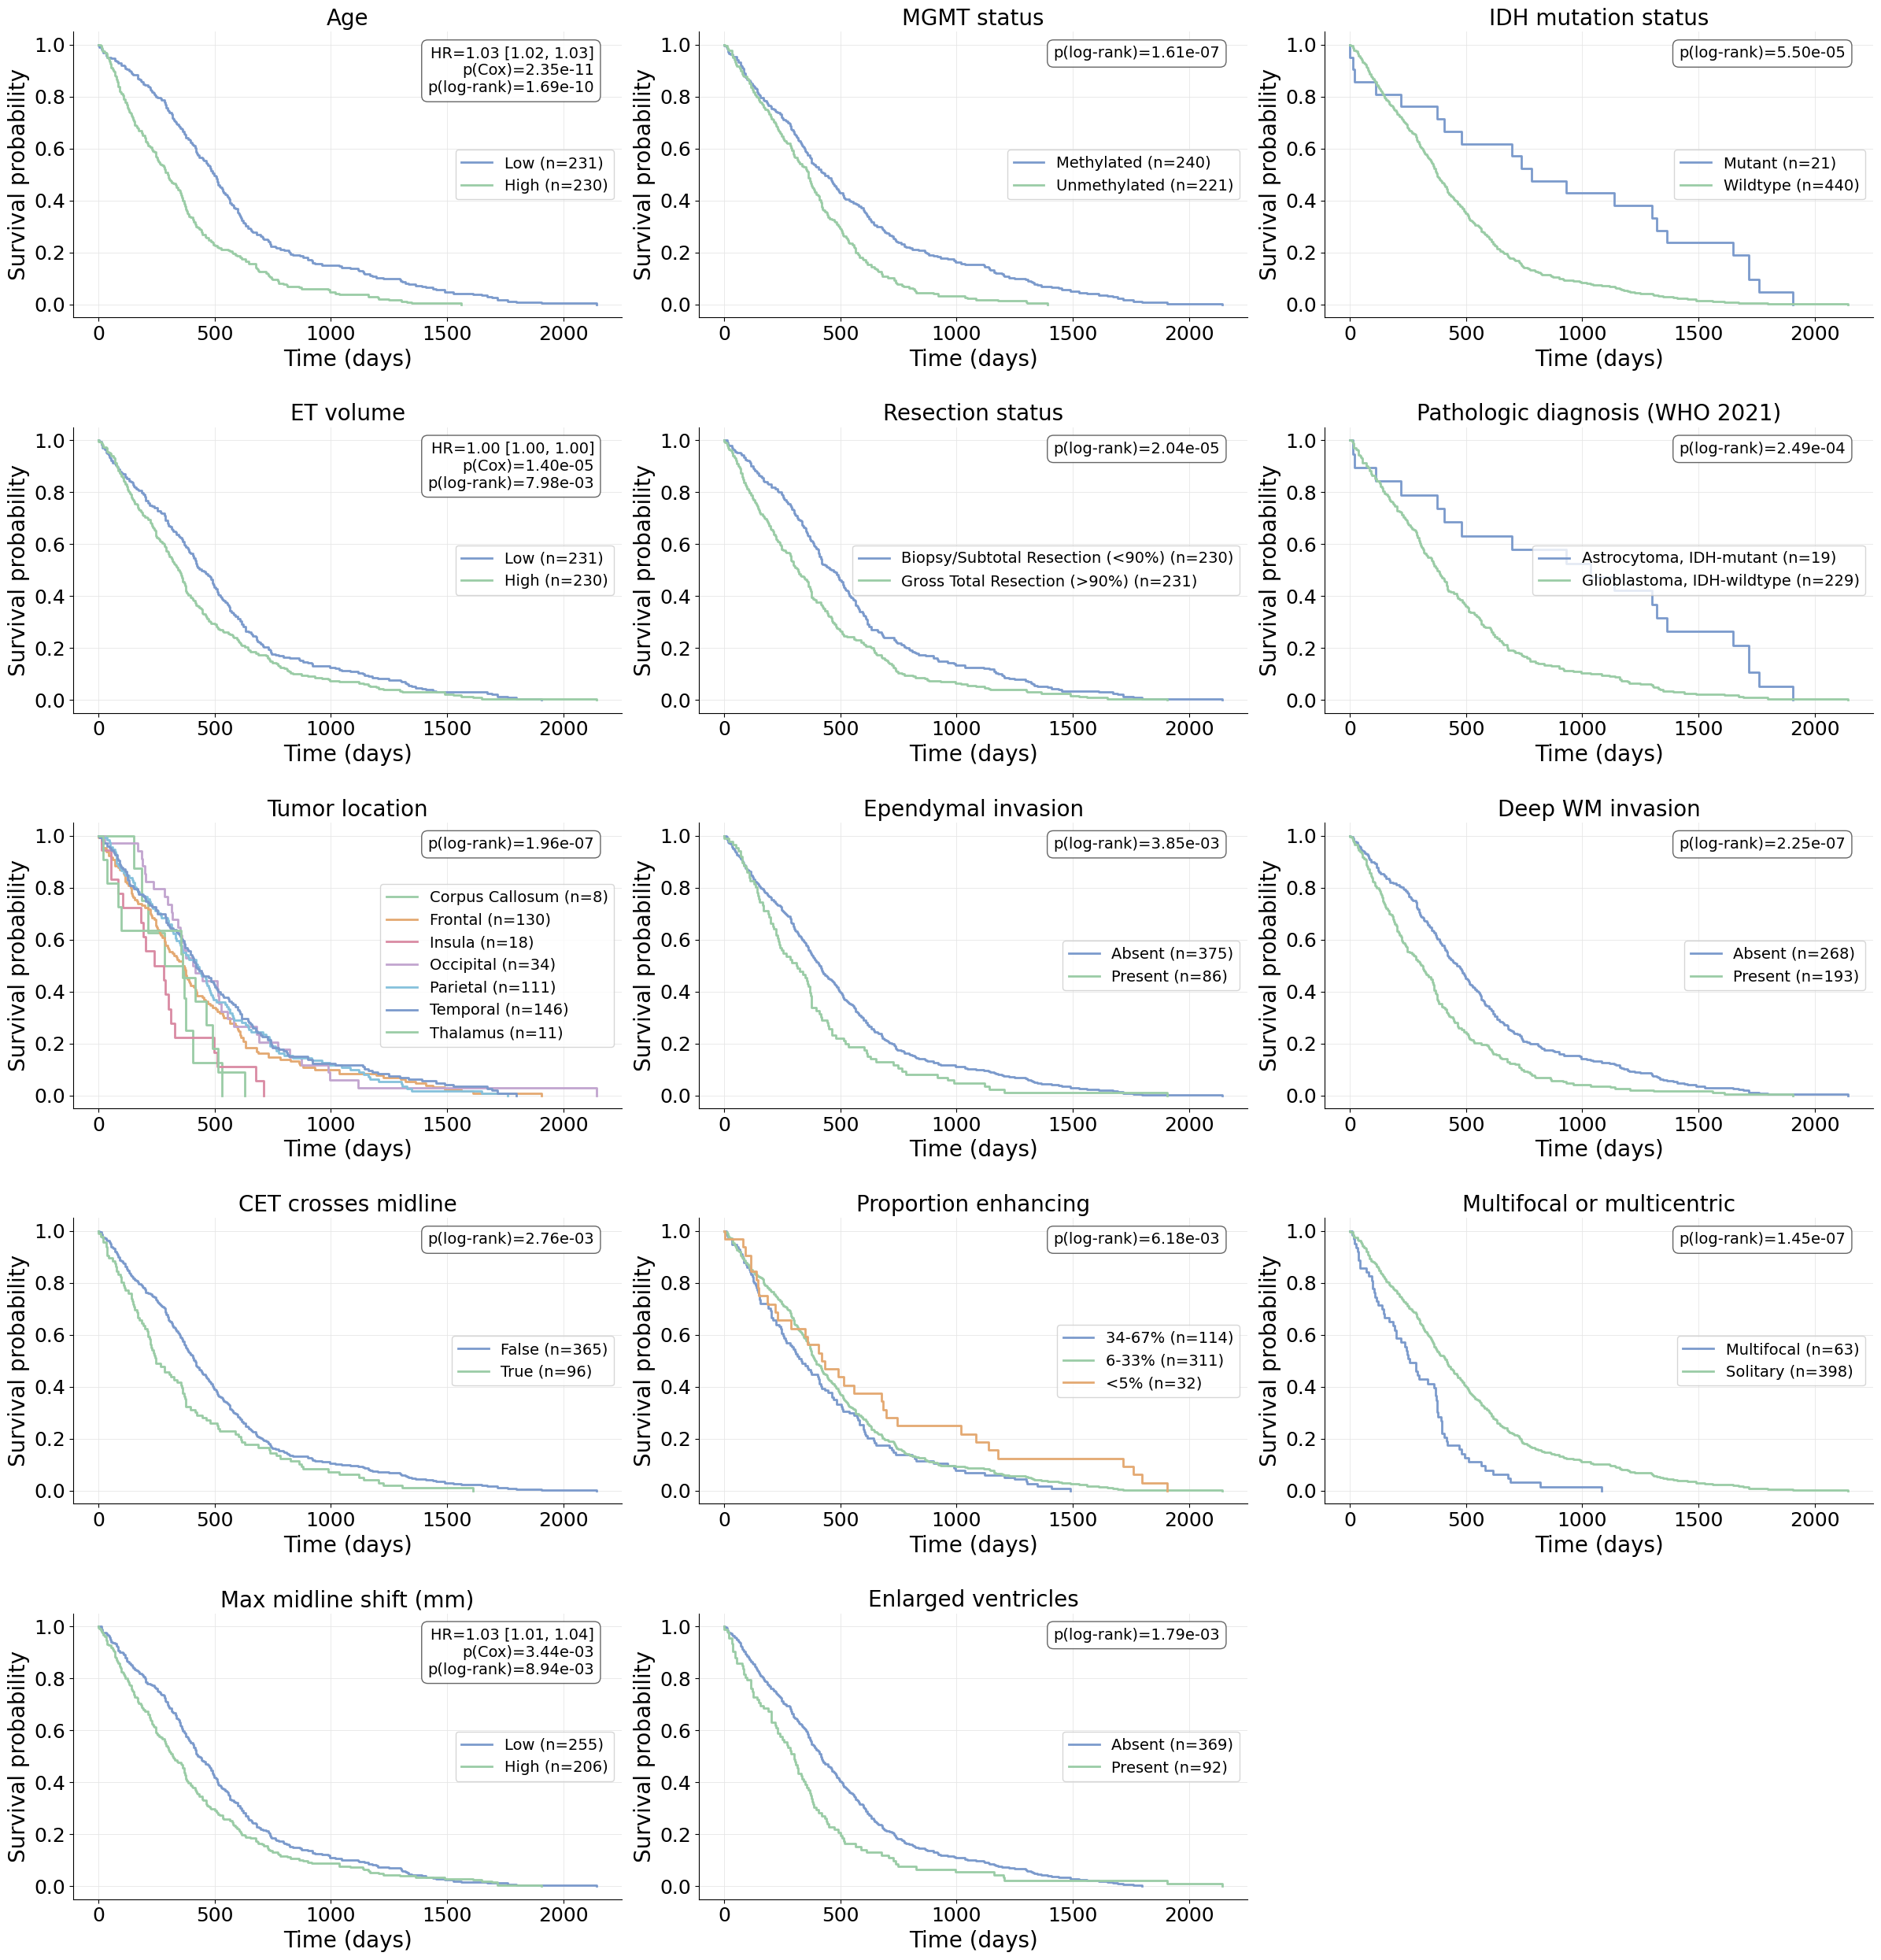

In [ ]:
features=[
'GBM_Subjects_Spreadsheet__age',
'GBM_Subjects_Spreadsheet__mgmt_status',
'GBM_Subjects_Spreadsheet__idh_status',
'GBM_Subjects_Spreadsheet__et_volume',
'GBM_Subjects_Spreadsheet__resection_status',
'UCSF-PDGM-Clinical__Final pathologic diagnosis (WHO 2021)',

 'brats23_metadata_flattened__global__vasari_f1_tumour_location',
 'brats23_metadata_flattened__global__vasari_f19_ependymal_invasion',
 'brats23_metadata_flattened__global__vasari_f21_deep_wm_invasion',
 'brats23_metadata_flattened__global__vasari_f23_cet_crosses_midline',
 'brats23_metadata_flattened__global__vasari_f5_proportion_enhancing',
 'brats23_metadata_flattened__global__vasari_f9_multifocal_or_multicentric',

'brats23_metadata_flattened__global__max_midline_shift_mm',
'brats23_metadata_flattened__global__level_max_shift',
'brats23_metadata_flattened__global__vasari_enlarged_ventricles',

]
plots_survival(df=merged_data,x_list=features, only_significant=True, alpha=0.05,save_path='./assets/allsig_vs_surv_KM.png',)


--- PERFORMANCE ---
Accuracy: 0.9568965517241379
ROC-AUC: 0.8162162162162162

--- CV ROC-AUC ---
Mean: 0.6066477272727273
Std: 0.11696566123906156

--- TOP POSITIVE FEATURES (Mutant) ---
brats23_metadata_flattened__global__vasari_f24_satellites_Present                      0.583098
brats23_metadata_flattened__global__vasari_f5_proportion_enhancing_<5%                 0.563568
brats23_metadata_flattened__global__vasari_f9_multifocal_or_multicentric_Solitary      0.373867
brats23_metadata_flattened__global__vasari_f1_tumour_location_Frontal                  0.317107
brats23_metadata_flattened__global__vasari_f7_proportion_necrosis_<5%                  0.297129
brats23_metadata_flattened__global__vasari_f23_cet_crosses_midline                     0.219747
brats23_metadata_flattened__global__vasari_f4_enhancement_quality_Mild                 0.204820
brats23_metadata_flattened__global__vasari_f19_ependymal_invasion_Present              0.136692
brats23_metadata_flattened__global__vasari_e

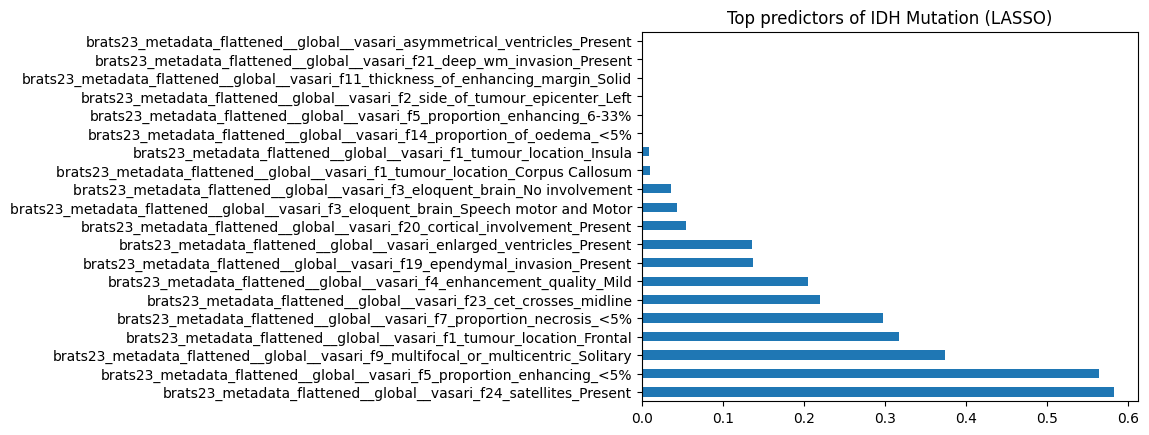

In [17]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ----------------------------------------------
# 1) Load data
# ----------------------------------------------

merged_data = pd.read_csv("btreport/patient_metadata/datasheets/cleaned_merged.csv")

# ----------------------------------------------
# 2) Target encoding (IDH mutant vs wildtype)
# ----------------------------------------------

y = LabelEncoder().fit_transform(merged_data['GBM_Subjects_Spreadsheet__idh_status'])

# ----------------------------------------------
# 3) Predictor selection: all VASARI features
# ----------------------------------------------

vasari_list = [k for k in merged_data.columns
               if "vasari" in k.lower() and not any(s in k.lower()
               for s in ["text_report", "region_proportions"])]

# Optionally add additional groups:
add_features = [
    'brats23_metadata_flattened__global__max_midline_shift_mm',
    # 'GBM_Subjects_Spreadsheet__age',
    # 'GBM_Subjects_Spreadsheet__sex',
    # 'GBM_Subjects_Spreadsheet__mgmt_status',
    # 'GBM_Subjects_Spreadsheet__resection_status'
]

use_features = vasari_list + add_features

X = merged_data[use_features].copy()

# ----------------------------------------------
# 4) Convert categoricals to one-hot
# ----------------------------------------------

categoricals = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=categoricals, drop_first=True)

# ----------------------------------------------
# 5) Train / Test split
# ----------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ----------------------------------------------
# 6) Pipeline: Impute -> Standardize -> LASSO
# ----------------------------------------------

pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=2000,
        C=1.0  # strength of LASSO (smaller = stronger regularization)
    ))
])

# ----------------------------------------------
# 7) Fit and evaluate
# ----------------------------------------------

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\n--- PERFORMANCE ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ----------------------------------------------
# 8) Cross-val AUC
# ----------------------------------------------

scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')

print("\n--- CV ROC-AUC ---")
print("Mean:", scores.mean())
print("Std:", scores.std())

# ----------------------------------------------
# 9) Coefficients / Feature importance
# ----------------------------------------------

pipeline.fit(X, y)  # fit on full set for interpretation

coefs = pipeline.named_steps["clf"].coef_[0]
importance = pd.Series(coefs, index=X.columns).sort_values(ascending=False)

print("\n--- TOP POSITIVE FEATURES (Mutant) ---")
print(importance.head(20))

print("\n--- TOP NEGATIVE FEATURES (Wildtype) ---")
print(importance.tail(20))

# Optional barplot
import matplotlib.pyplot as plt

importance.head(20).plot(kind='barh')
plt.title("Top predictors of IDH Mutation (LASSO)")
plt.show()



--- PERFORMANCE ---
Accuracy: 0.5
ROC-AUC: 0.5282738095238095

--- CV ROC-AUC ---
Mean: 0.5076010101010102
Std: 0.0267936288007631

--- TOP POSITIVE FEATURES (Mutant) ---
brats23_metadata_flattened__global__vasari_f3_eloquent_brain_Speech motor and Motor     0.435650
brats23_metadata_flattened__global__vasari_f3_eloquent_brain_No involvement             0.280364
brats23_metadata_flattened__global__vasari_f23_cet_crosses_midline                      0.243413
brats23_metadata_flattened__global__vasari_f3_eloquent_brain_Vision                     0.233466
brats23_metadata_flattened__global__vasari_f14_proportion_of_oedema_6-33%               0.211486
brats23_metadata_flattened__global__vasari_f9_multifocal_or_multicentric_Solitary       0.176005
brats23_metadata_flattened__global__vasari_f1_tumour_location_Frontal                   0.147066
brats23_metadata_flattened__global__vasari_f3_eloquent_brain_Speech motor               0.144366
brats23_metadata_flattened__global__vasari_f1_tumour

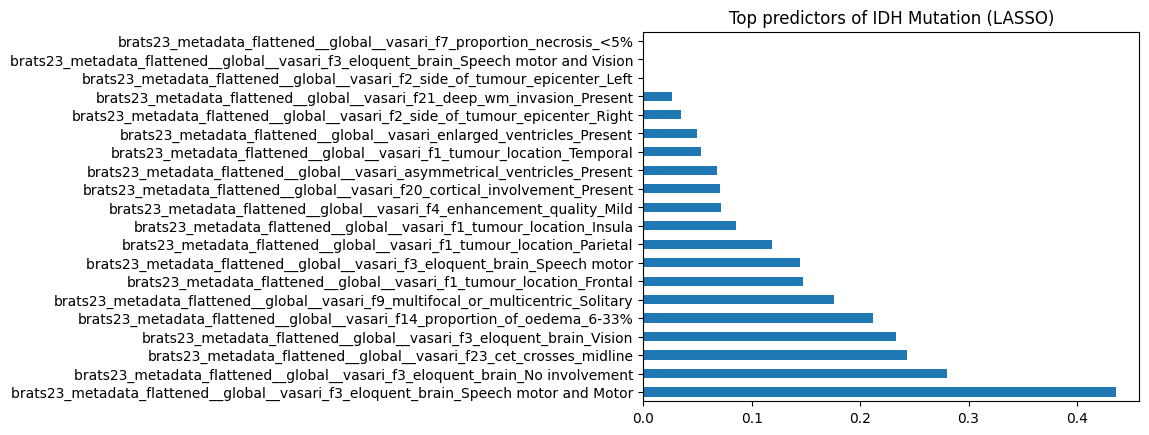

In [18]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# ----------------------------------------------
# 1) Load data
# ----------------------------------------------

merged_data = pd.read_csv("btreport/patient_metadata/datasheets/cleaned_merged.csv")

# ----------------------------------------------
# 2) Target encoding (IDH mutant vs wildtype)
# ----------------------------------------------

y = LabelEncoder().fit_transform(merged_data["GBM_Subjects_Spreadsheet__mgmt_status"])

# ----------------------------------------------
# 3) Predictor selection: all VASARI features
# ----------------------------------------------

vasari_list = [k for k in merged_data.columns
               if "vasari" in k.lower() and not any(s in k.lower()
               for s in ["text_report", "region_proportions"])]

# Optionally add additional groups:
add_features = [
    'brats23_metadata_flattened__global__max_midline_shift_mm',
    # 'GBM_Subjects_Spreadsheet__age',
    # 'GBM_Subjects_Spreadsheet__sex',
    # 'GBM_Subjects_Spreadsheet__mgmt_status',
    # 'GBM_Subjects_Spreadsheet__resection_status'
]

use_features = vasari_list + add_features

X = merged_data[use_features].copy()

# ----------------------------------------------
# 4) Convert categoricals to one-hot
# ----------------------------------------------

categoricals = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=categoricals, drop_first=True)

# ----------------------------------------------
# 5) Train / Test split
# ----------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ----------------------------------------------
# 6) Pipeline: Impute -> Standardize -> LASSO
# ----------------------------------------------

pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        max_iter=2000,
        C=1.0  # strength of LASSO (smaller = stronger regularization)
    ))
])

# ----------------------------------------------
# 7) Fit and evaluate
# ----------------------------------------------

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\n--- PERFORMANCE ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# ----------------------------------------------
# 8) Cross-val AUC
# ----------------------------------------------

scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')

print("\n--- CV ROC-AUC ---")
print("Mean:", scores.mean())
print("Std:", scores.std())

# ----------------------------------------------
# 9) Coefficients / Feature importance
# ----------------------------------------------

pipeline.fit(X, y)  # fit on full set for interpretation

coefs = pipeline.named_steps["clf"].coef_[0]
importance = pd.Series(coefs, index=X.columns).sort_values(ascending=False)

print("\n--- TOP POSITIVE FEATURES (Mutant) ---")
print(importance.head(20))

print("\n--- TOP NEGATIVE FEATURES (Wildtype) ---")
print(importance.tail(20))

# Optional barplot
import matplotlib.pyplot as plt

importance.head(20).plot(kind='barh')
plt.title("Top predictors of IDH Mutation (LASSO)")
plt.show()
